In [7]:
!pip install gym==0.17.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 34.2 MB/s eta 0:00:00
  Created wheel for gym: filename=gym-0.17.3-py3-none-any.whl size=1654617 sha256=1e4453a4969e8df16afb310a6d509a3aff8bc1e778973aaa6807af61bfb37693
  Stored in directory: /root/.cache/pip/wheels/99/7e/03/69cdeb432380e05bc9a56ff68451d8063e41aa06db508f4be5
Successfully built gym
  Attempting uninstall: cloudpickle
    Found existing installation: cloudpickle 3.1.2
    Uninstalling cloudpickle-3.1.2:
      Successfully uninstalled cloudpickle-3.1.2
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires cloudpickl

In [8]:
import gym
import random
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

In [9]:
entorno = gym.make('Blackjack-v0')

In [10]:
#Acciones: plantarse = 0 y pedir = 1
print(entorno.action_space)

#Estados es una tupla de 3 elementos (suma agente, carta dealer, As usable)
print(entorno.observation_space)

Discrete(2)
Tuple(Discrete(32), Discrete(11), Discrete(2))


In [11]:
#Para jugar un episodio

estado = entorno.reset()
while True:
  #mostrar las cartas del dealer y el jugador
  print(f'Cartas del dealer: {entorno.dealer}')
  print(f'Cartas del jugador: {entorno.player}')

  #imprimir estado
  print(f'Estado:, {estado}')
  print(f'\tSuma: {estado[0]}')
  print(f'\tCarta descubierta del dealer: {estado[1]}')
  print(f'\t¿Jugador tiene carta AS Usable? : {estado[2]}')

  accion = entorno.action_space.sample()
  if accion == 1: #pedir
    print('Acción: seguir jugando')
  else:
    print('Accion: plantarse')

  #Ejecutar jugada
  estado, recompensa, done, info = entorno.step(accion)
  if done:
    print(f'Fin del juego. Recompensa: {recompensa}')
    if recompensa > 0:
      print('Ganaste')
    else:
      print('Perdiste')
    break

Cartas del dealer: [5, 6]
Cartas del jugador: [10, 10]
Estado:, (20, 5, False)
	Suma: 20
	Carta descubierta del dealer: 5
	¿Jugador tiene carta AS Usable? : False
Acción: seguir jugando
Fin del juego. Recompensa: -1.0
Perdiste


Prediccion (evaluar) con Monte Carlo

In [12]:
#Politica 1: arbitraria
#Politica 2: Elm jugador se planta siempre que la suma de las cartas nos pase un umbral >18

def politica_1(s):
  'Politica aleatoria'
  return random.randint(0,1)


umbral = 18

def politica_2(s):
  suma, carta_dealer, as_usable = s
  if suma > umbral:
    return 0 #plantarse
  else:
    return 1 #pedir

In [13]:
#Funcion para generar un episodio

def generar_episodio(entorno, pi):
  episodio = []
  done = True
  while True:
    if done:
      St, Rt, done = entorno.reset(), None, False
    else: #Hacer que el agente interactue con el entorno
      St, Rt, done, info = entorno.step(At)

    #generar accion y añadir traycetoriuo a la lista de episodios
    At = pi(St)
    episodio.append((St, Rt, done, At))

    if done:
      break
  return episodio, len(episodio)-1

In [14]:
#Probar
episodio, longitud = generar_episodio(entorno, politica_2)
print(f'Episodio: {episodio}')
print(f'Longitud (steps): {longitud}')

Episodio: [((15, 9, False), None, False, 1), ((18, 9, False), 0.0, False, 1), ((27, 9, False), -1.0, True, 0)]
Longitud (steps): 2


Prediccion (evaluar) monte Carlo de primera visita

In [15]:
def prediccion_MC_visita1(entorno, pol, neps, gamma): # neps =  Numero de episodios
  V = {} #Funciuon estado valor
  Retornos = defaultdict(list)  #Paa cada estado será una ñista vacia

  for ep in range(neps):
    episodio, T = generar_episodio(entorno,pol)
    G = 0 #acumulador de retornos

    for t in range(T-1, -1, -1): #por cada iteracion (paso) extraer estado, recomp, accion
      St, _ , _ , At = episodio[t]
      _, Rt1, _, _ = episodio[t+1]

      #Actualizar retorno
      G = gamma*G + Rt1

      #promediar solo si es primera visita
      for i in range(0,t):
        if St not in episodio[i][0]:
          Retornos[St].append(G)
          V[St] = np.average(Retornos[St])
  return V, Retornos

In [16]:
#probar con gamma =1
V, Retornos = prediccion_MC_visita1(entorno, politica_1, neps=2000, gamma=1)

In [17]:
from ast import Yield
#Graficar

def graficar_V(V, titulo=''):

  def crearXY(V):
    x_min =  min(k[0]  for k in V.keys()) #suma
    x_max =  max(k[0]  for k in V.keys())
    y_min =  min(k[1]  for k in V.keys()) #carta dealer
    y_max =  max(k[1]  for k in V.keys())

    x_val = np.arange(x_min, x_max+1)
    y_val = np.arange(y_min, y_max+1)
    X, Y = np.meshgrid(x_val, y_val) #grid

    return X, Y

  def extraerZ(x, y, as_usable):
    if (x,y,as_usable) in V:
      return V[x,y,as_usable]
    else:
      return 0

  def crear_superficie(as_usable, ax):
    X, Y = crearXY(V)
    Z = np.array([extraerZ(x, y, as_usable) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

    surf = ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=plt.cm.coolwarm, vmin=-1, vmax=1)
    ax.set_xlabel('Suma', fontsize=8)
    ax.set_ylabel('Carta del dealer', fontsize=8)
    ax.set_ylabel('Valor del estadoi', fontsize=8)
    ax.view_init(ax.elev, -120)

  fig = plt.figure(figsize=(10,4))
  fig.title(titulo, fontsize=6)

  ax = fig.add_subplot(1,2,1, projection='3d')
  ax.set_title('As Usable')
  crear_superficie(True, ax)

  ax = fig.add_subplot(1,2,2, projection='3d')
  ax.set_title('As No Usable')
  crear_superficie(False, ax)
  plt.show()

In [18]:
from ast import Yield
#Graficar

def graficar_V(V, titulo=''):

  def crearXY(V):
    x_min =  min(k[0]  for k in V.keys()) #suma
    x_max =  max(k[0]  for k in V.keys())
    y_min =  min(k[1]  for k in V.keys()) #carta dealer
    y_max =  max(k[1]  for k in V.keys())

    x_val = np.arange(x_min, x_max+1)
    y_val = np.arange(y_min, y_max+1)
    X, Y = np.meshgrid(x_val, y_val) #grid

    return X, Y

  def extraerZ(x, y, as_usable):
    if (x,y,as_usable) in V:
      return V[x,y,as_usable]
    else:
      return 0

  def crear_superficie(as_usable, ax):
    X, Y = crearXY(V)
    Z = np.array([extraerZ(x, y, as_usable) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

    surf = ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=plt.cm.coolwarm, vmin=-1, vmax=1)
    ax.set_xlabel('Suma', fontsize=8)
    ax.set_ylabel('Carta del dealer', fontsize=8)
    ax.set_zlabel('Valor del estadoi', fontsize=8) # Corrected label to set_zlabel
    ax.view_init(ax.elev, -120)

  fig = plt.figure(figsize=(8,4))
  fig.suptitle(titulo, fontsize=12) # Changed fig.title to fig.suptitle and adjusted fontsize for better visibility

  ax = fig.add_subplot(1,2,1, projection='3d')
  ax.set_title('As Usable')
  crear_superficie(True, ax)

  ax = fig.add_subplot(1,2,2, projection='3d')
  ax.set_title('As No Usable')
  crear_superficie(False, ax)
  plt.show()

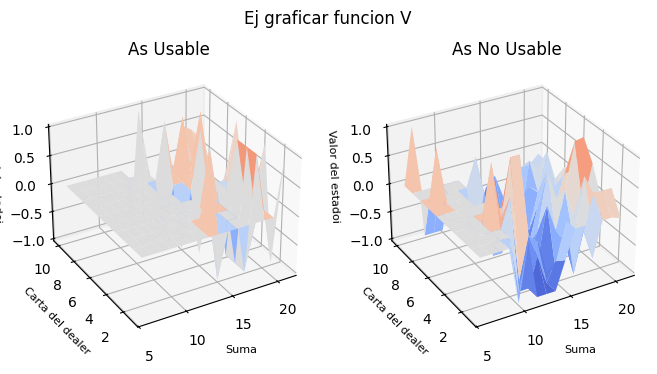

In [19]:
graficar_V(V, 'Ej graficar funcion V')

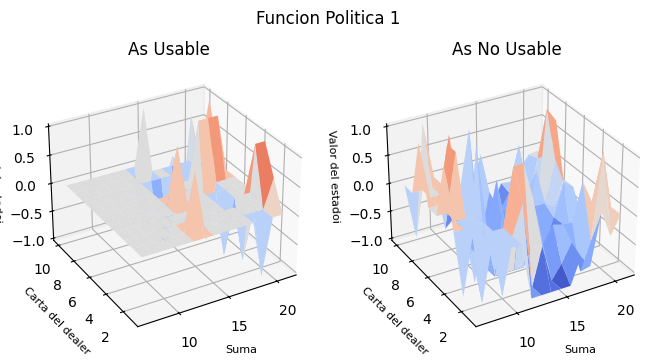

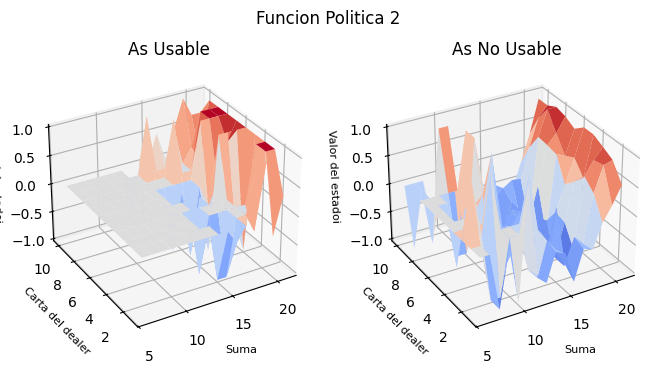

In [20]:
V1, _ = prediccion_MC_visita1(entorno, politica_1, neps=2000, gamma=1)
V2, _ = prediccion_MC_visita1(entorno, politica_2, neps=2000, gamma=1)
graficar_V(V1, 'Funcion Politica 1')
graficar_V(V2, 'Funcion Politica 2')

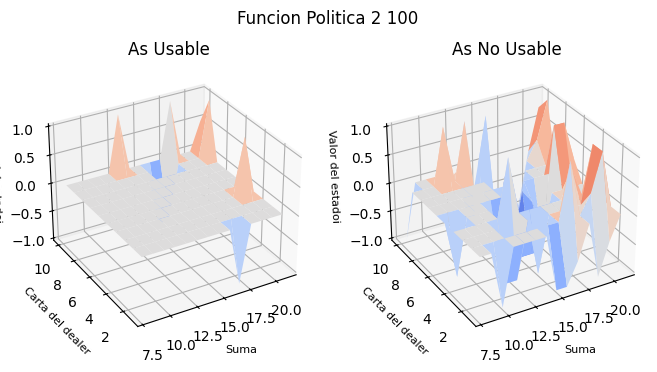

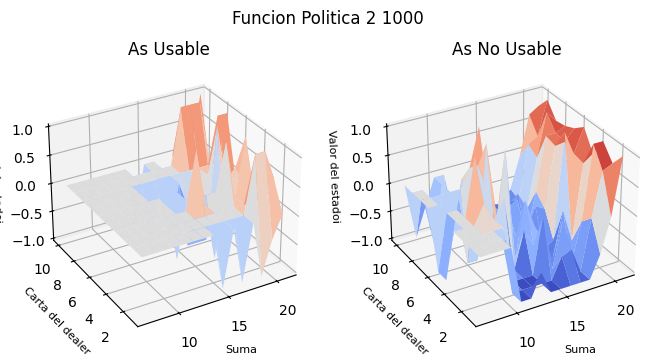

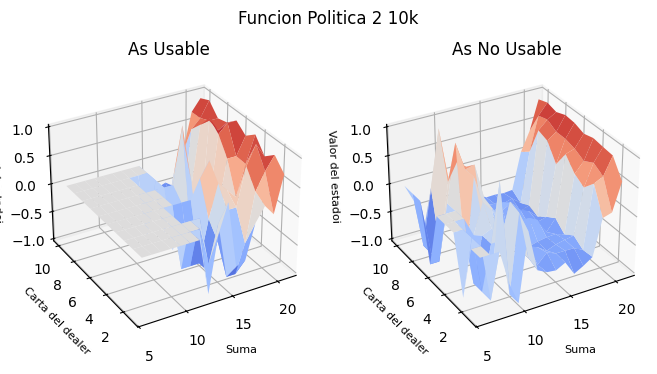

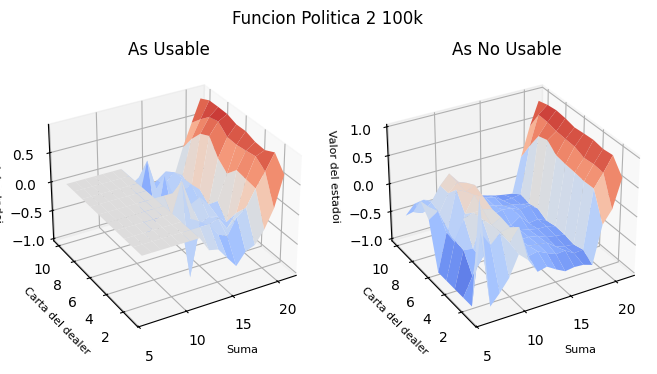

In [21]:
V3, _ = prediccion_MC_visita1(entorno, politica_2, neps=100, gamma=1)
V4, _ = prediccion_MC_visita1(entorno, politica_2, neps=1000, gamma=1)
V5, _ = prediccion_MC_visita1(entorno, politica_2, neps=10000, gamma=1)
V6, _ = prediccion_MC_visita1(entorno, politica_2, neps=100000, gamma=1)
graficar_V(V3, 'Funcion Politica 2 100')
graficar_V(V4, 'Funcion Politica 2 1000')
graficar_V(V5, 'Funcion Politica 2 10k')
graficar_V(V6, 'Funcion Politica 2 100k')

CLASE 19/05/2026

Control de Monte Carlo 'on policy' algoritmo e greedy


In [22]:
N_ACCIONES = 2
ACCIONES = [0,1]

def inicializar_politica(St, pi):
  return np.random.choice(ACCIONES, p=[pi[(St,a)] for a in ACCIONES])

def argmax_aleatorio(arreglo):
  return np.random.choice(np.flatnonzero(arreglo == np.max(arreglo)))

def generar_episodio_control(entorno, politica, *params):
  episodio = []
  done = True

  while True:
    if done:
      St, Rt, done = entorno.reset(), None, False
    else:
      St, Rt, done, _ = entorno.step(At)

    At = politica(St, *params)
    episodio.append((St, Rt, done, At))

    if done:
      break
  return episodio, len(episodio)-1

In [23]:
def control_MC_on_policy(entorno, neps, gamma, epsilon):
  #inicializar pi, Q, retornos
  pi = defaultdict(lambda: 1/N_ACCIONES) #todas las acciones con igual probabilidad
  Q = defaultdict(lambda: np.zeros(N_ACCIONES))
  Retornos = defaultdict(list)

  for ep in range(neps):
    episodio, T = generar_episodio_control(entorno, inicializar_politica, pi)
    G = 0

    for t in range(T-1, -1, -1):
      #obtener estado, accion en t y recompensa en t+1
      St, _, _, At = episodio[t]
      _, Rt1, _, _ = episodio[t+1]

      #actualizamos el retorno
      G = gamma*G + Rt1

      #actualizamos funcion accion valor
      if (St, At) not in [(episodio[i][0], episodio[i][3]) for i in range(0,t)]:
        #actualizar retornos y funcion accion valor
        Retornos[(St, At)].append(G)
        Q[St][At] = np.average(Retornos[(St, At)])

        #obtener ola mejor acción(optima) para el estado actual St
        A_optima = argmax_aleatorio([Q[St][a] for a in range(N_ACCIONES)])

        #Mejorar la politica usando epsilon greedy
        for a in range(N_ACCIONES):
          if a == A_optima:
            pi[(St, a)] = 1 - epsilon + epsilon/N_ACCIONES
          else:
            pi[(St, a)] = epsilon/N_ACCIONES

  return Q, pi

In [30]:
#Probamos funcion control MC epsilon greedy
Q, pi = control_MC_on_policy(entorno, neps=100000, gamma=0.9, epsilon=0.2)

In [31]:
#Evaluar la politica recien obtenida
V_MC_on = defaultdict(float)

for estado, acciones in Q.items():
  valor = np.max(acciones)
  V_MC_on[estado] = valor

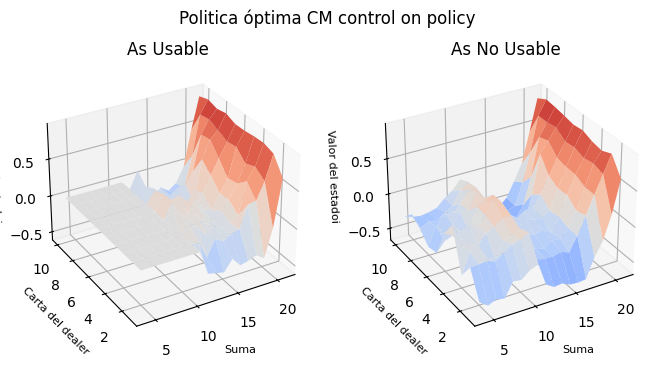

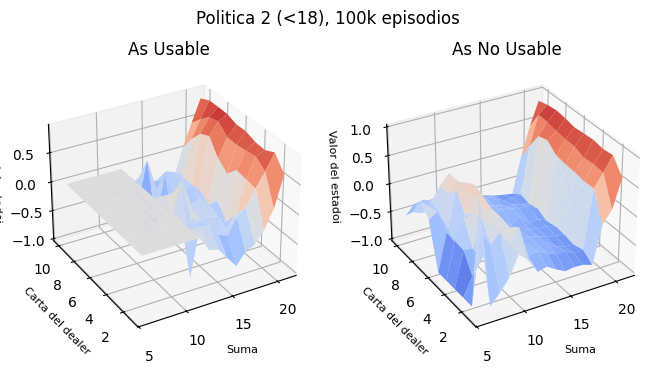

In [32]:
graficar_V(V_MC_on, 'Politica óptima CM control on policy')
graficar_V(V6, 'Politica 2 (<18), 100k episodios')

In [33]:
#Comparación cuántitativa
diferencias = []

for estado, valor in V6.items():
  if estado in V_MC_on:
    diferencia = V_MC_on[estado] - valor
    diferencias.append(diferencia)
print(np.average(diferencias))

0.1454817101064057


Control Monte Carlo 'off policy'

In [34]:
def control_MC_off_policy(entorno, neps, b, gamma):
  #inicializar pi, Q, C(pesos)
  pi = defaultdict(lambda: 1/N_ACCIONES) #politica a optimizar
  Q = defaultdict(lambda: np.zeros(N_ACCIONES))
  C = defaultdict(lambda: np.zeros(entorno.action_space.n))

  for ep in range(neps):
    episodio, T = generar_episodio_control(entorno, inicializar_politica, b)
    G = 0  #acumulador del retorno
    W = 1.0  #tasa de importancia de muestreo se actualiza en cada iteración

    for t in range(T-1, -1, -1):
      #obtener estado, accion en t y recompensa en t+1
      St, _, _, At = episodio[t]
      _, Rt1, _, _ = episodio[t+1]

      #actualizamos el retorno
      G = gamma*G + Rt1

      #Actualizar acumulador de los pesos C
      C[St][At] += W

      #Actualizar funcion accion valor asociada a pi
      Q[St][At] += (W/C[St][At])*(G-Q[St][At])

      #obtener ola mejor acción(optima) para el estado actual St
      A_optima = argmax_aleatorio([Q[St][a] for a in range(N_ACCIONES)])

      for a in range(N_ACCIONES):
        if a == A_optima:
          pi[(St, a)] = 1
        else:
          pi[(St, a)] = 0

      #ACTUALIZAR RAZÓN IMPORTANCIA MUESTREO
      W = W*1./b[(St, At)]  #1 sobre b porque pi es codicioso

  return Q, pi

In [35]:
#probar
b = defaultdict(lambda: 1/N_ACCIONES)  #Politica aleatoria
Q, pi = control_MC_off_policy(entorno, neps=100000, b=b, gamma=0.9)

In [36]:
#Evaluar la politica recien obtenida
V_MC_off = defaultdict(float)

for estado, acciones in Q.items():
  valor = np.max(acciones)
  V_MC_off[estado] = valor

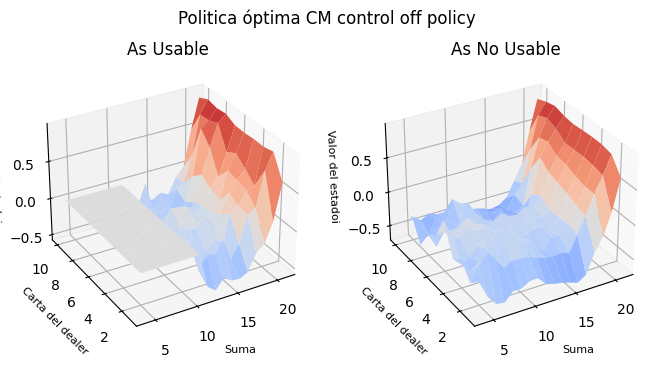

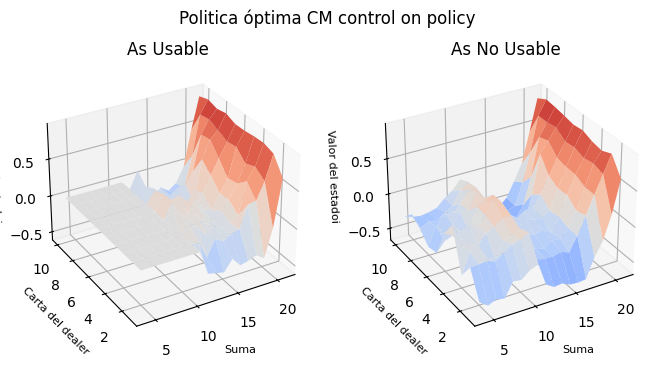

In [37]:
graficar_V(V_MC_off, 'Politica óptima CM control off policy')
graficar_V(V_MC_on, 'Politica óptima CM control on policy')

In [38]:
#Comparación cuántitativa
diferencias = []

for estado, valor in V_MC_off.items():
  if estado in V_MC_on:
    diferencia = V_MC_on[estado] - valor
    diferencias.append(diferencia)
print(np.average(diferencias))

0.07281512070177552
